# RNN 語言模型

## 文字的處理

讀取 `data/shakespeare.txt` 文字檔的內容，並對檔案中的字元做基本統計與預覽，包含：

- 計算整份文字的總字元數
- 建立不重複字元的字元表
- 計算字元表大小
- 顯示字元表前 10 個字元
- 顯示原始文字前 148 個字元內容

In [11]:
# 指定要讀取的文字檔路徑
filename = 'data/shakespeare.txt'

# 讀取整個文字檔內容
data = open(filename, 'r').read()
# 取得資料中所有不重複字元，建立字元表
chars = list(set(data))
# 計算全文字元總數與不重複字元數量
data_size, vocab_size = len(data), len(chars)

# 輸出資料集的基本統計資訊
print ('字元總數 %d, 字符表的長度 %d unique.' % (data_size, vocab_size))
# 顯示字元表中的前 10 個字元，方便快速查看字元組成
print('字元表中的前 10 個字元：\n',chars[:10])
# 顯示原始文字前 148 個字元，作為資料內容預覽
print('前 148 個字元：\n',data[:148])

字元總數 1115394, 字符表的長度 65 unique.
字元表中的前 10 個字元：
 ['M', 'C', 'S', 'P', 'E', 'W', 'I', 'b', 'c', 'd']
前 148 個字元：
 First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?



這段程式碼延續前面的字元表處理結果，進一步建立字元與索引之間的雙向映射，並定義一個 `one_hot_idx` 函式，將指定索引轉成 one-hot 向量表示。


In [ ]:
import numpy as np

# 建立字元到索引的映射表，方便將文字資料轉成模型可處理的數值表示
char_to_idx = { ch:i for i,ch in enumerate(chars) }

# 建立索引到字元的映射表，方便之後將模型輸出還原成文字
idx_to_char = { i:ch for i,ch in enumerate(chars) }

# 輸出雙向映射內容，確認字元表與索引配置是否正確
print('字元到索引的映射：\n', char_to_idx)
print('索引到字元的映射：\n', idx_to_char)

def one_hot_idx(idx, vocab_size):  
    # 建立一個大小為 (1, vocab_size) 的全 0 向量
    x = np.zeros((1, vocab_size)) 

    # 將指定索引位置設為 1，形成 one-hot 表示
    x[0, idx] = 1  

    # 回傳 one-hot 向量
    return x

# 測試 one_hot_idx 函數，將索引 1 轉換為 one-hot 向量
test_idx = 1
one_hot_vector = one_hot_idx(test_idx, vocab_size)

# 輸出測試結果
print('索引 %d 的 one-hot 向量：\n' % test_idx, one_hot_vector)

字元到索引的映射：
 {'M': 0, 'C': 1, 'S': 2, 'P': 3, 'E': 4, 'W': 5, 'I': 6, 'b': 7, 'c': 8, 'd': 9, 'g': 10, 'u': 11, 'D': 12, 'F': 13, 'K': 14, ';': 15, 'f': 16, 'G': 17, 'V': 18, 'e': 19, '!': 20, 'H': 21, "'": 22, 'U': 23, '.': 24, '\n': 25, 'Z': 26, 'Y': 27, 'y': 28, 'a': 29, 'Q': 30, '-': 31, 'v': 32, 'L': 33, 'w': 34, 'J': 35, '&': 36, 'O': 37, 'X': 38, ' ': 39, 'A': 40, 's': 41, 'T': 42, 'z': 43, 'R': 44, 'x': 45, 'l': 46, ',': 47, 'q': 48, '3': 49, ':': 50, 'n': 51, 'm': 52, 'p': 53, 'k': 54, '$': 55, 'r': 56, 'B': 57, 'h': 58, '?': 59, 'i': 60, 'j': 61, 'o': 62, 't': 63, 'N': 64}
索引到字元的映射：
 {0: 'M', 1: 'C', 2: 'S', 3: 'P', 4: 'E', 5: 'W', 6: 'I', 7: 'b', 8: 'c', 9: 'd', 10: 'g', 11: 'u', 12: 'D', 13: 'F', 14: 'K', 15: ';', 16: 'f', 17: 'G', 18: 'V', 19: 'e', 20: '!', 21: 'H', 22: "'", 23: 'U', 24: '.', 25: '\n', 26: 'Z', 27: 'Y', 28: 'y', 29: 'a', 30: 'Q', 31: '-', 32: 'v', 33: 'L', 34: 'w', 35: 'J', 36: '&', 37: 'O', 38: 'X', 39: ' ', 40: 'A', 41: 's', 42: 'T', 43: 'z', 44: 'R', 45: 

## 字元序列樣本採樣

這段程式碼定義了一個 `character_seq_data_iter_consecutive` 產生器函式，用來從文字資料中，以「連續切分」的方式產生訓練用序列批次資料。

它的主要用途是把原始字元序列切成多個 batch，並在每個 batch 中持續取出固定長度的序列片段，供序列模型訓練使用。每次輸出會同時提供：

- `X`：目前時間步的輸入序列
- `Y`：對應下一個字元的目標序列
- 是否為該輪第一個 batch 的標記值

In [16]:
import numpy as np

def character_seq_data_iter_consecutive(data, batch_size, seq_len,start_range=10):
      # 每次從 data 的隨機起始偏移位置開始取樣，讓不同 epoch 的樣本切法有所變化
    start = np.random.randint(0, start_range)

    # 計算每個 batch 區塊可分配到的有效資料長度
    block_len = (len(data)-start-1) // batch_size

    # 計算每個區塊最多可以連續切出幾個長度為 seq_len 的批次
    num_batches = block_len // seq_len

    # 建立每個 block 的起始位置
    bs = np.array(range(0,block_len*batch_size,block_len) )

    # 可實際使用的總序列長度
    i_end = num_batches * seq_len

    # 依序取出每一段長度為 seq_len 的連續序列
    for i in range(0, i_end, seq_len): # 一個 block 的序列開始位置
        s = start+i                    # 目前在單一 block 內的起始位置

        # 建立輸入序列 X 與目標序列 Y
        X = np.empty((seq_len,batch_size),dtype=object)
        Y = np.empty((seq_len,batch_size),dtype=object)

        # 逐一填入 batch 中每個樣本的序列內容
        for b in range(batch_size): # b 表示一個批次中的第幾個樣本
            s_b = s+bs[b]

            # 依時間步逐一填入輸入與對應下一步目標
            for t in range(seq_len):
                X[t,b] = data[s_b]
                Y[t,b] = data[s_b+1]
                s_b +=1

        # 第一個 batch 額外回傳 True，供外部流程判斷是否為新一輪起始
        if i==0:
            yield X,Y,True
        else:
            yield X,Y,False

測試這個資料產生器是否能正確產生序列批次資料。

In [17]:
# 建立測試用字串資料
x = 'Li,where are you from'

# 設定每個 batch 的樣本數
batch_size = 2

# 設定序列長度（每個樣本的時間步長）
seq_length  = 3

# 建立連續序列資料迭代器
data_it = character_seq_data_iter_consecutive(x,batch_size,seq_length,1)

# 用來控制只觀察前幾個 batch
i = 0 

# 逐批從資料迭代器取出序列資料
for x,y,_ in data_it:

    # 印出輸入序列
    print("x:",x)

    # 印出對應的目標序列（下一個字元）
    print("y",y)

    # 批次計數
    i+=1

    # 只顯示前兩個 batch
    if i==2:break

x: [['L' 'r']
 ['i' 'e']
 [',' ' ']]
y [['i' 'e']
 [',' ' ']
 ['w' 'y']]
x: [['w' 'y']
 ['h' 'o']
 ['e' 'u']]
y [['h' 'o']
 ['e' 'u']
 ['r' ' ']]


這段程式碼將先前的連續序列資料產生器進一步擴充，讓輸入 `X` 直接轉成 one-hot 編碼格式，並將目標 `Y` 轉成對應字元索引，方便後續直接拿來做字元級序列模型訓練。


In [18]:
def character_seq_data_iter_consecutive(data, batch_size, seq_len,vocab_size,start_range=10):
      # 每次在資料中隨機選一個起始偏移位置，讓每個 epoch 的切樣方式略有不同
    start = np.random.randint(0, start_range)

    # 計算每個 batch block 可使用的有效資料長度
    block_len = (len(data)-start-1) // batch_size

    # 計算每個 block 最多可以連續切出幾個長度為 seq_len 的批次
    num_batches = block_len // seq_len

    # 建立每個 block 的起始位置偏移量
    bs = np.array(range(0,block_len*batch_size,block_len) )

    # 可實際使用的總時間步長
    i_end = num_batches * seq_len

    # 逐段取出固定長度的連續序列
    for i in range(0, i_end, seq_len):
        s = start+i

        # X 儲存 one-hot 編碼後的輸入序列
        X = np.empty((seq_len,batch_size,vocab_size),dtype = np.int32)

        # Y 儲存下一個字元的索引值
        Y = np.empty((seq_len,batch_size,1),dtype = np.int32)

        # 逐一填入 batch 中每個樣本的資料
        for b in range(batch_size):
            s_b = s+bs[b]

            # 依時間步建立輸入與標籤
            for t in range(seq_len):
                # 將目前字元轉成索引後，再轉成 one-hot 向量
                X[t,b,:] = one_hot_idx(char_to_idx[data[s_b]],vocab_size)

                # 將下一個字元轉成索引，作為預測目標
                Y[t,b,:] = char_to_idx[data[s_b+1]]
                s_b +=1

        # 第一個 batch 額外回傳 True，方便外部流程判斷是否為起始批次
        if i==0:
            yield X,Y,True
        else:
            yield X,Y,False

In [19]:
# 建立測試用字串
x = 'Li,where are you from'

# 設定 batch 大小
batch_size = 2

# 設定序列長度
seq_length  = 3

# 建立資料迭代器
data_it = character_seq_data_iter_consecutive(x,batch_size,seq_length,vocab_size,1)

# 用來限制只印出前兩個 batch
i = 0

# 逐批讀取並顯示資料內容
for x,y,_ in data_it:
    print("x:",x)
    print("y",y)
    i+=1
    if i==2:break

x: [[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0
   0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0]]

 [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]

 [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
   0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]]]
y [[[60]
  [19]]

 [[47]
  [39]]

 [[34]
  [28]]]
x: [[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
   0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 

In [31]:
import numpy as np
import modules.rnn as fr

batch_size = 1
input_dim = vocab_size
output_dim= vocab_size
hidden_size=100
params = fr.rnn_params_init(input_dim, hidden_size,output_dim)
H = fr.rnn_hidden_state_init(batch_size,hidden_size)

In [30]:
def rnn_forward_step(params,X, preH):
    Wx, Wh, bh, Wf, bf = params     
    H = np.tanh(np.dot(X, Wx) + np.dot(preH, Wh) + bh)
    F = np.dot(H, Wf) + bf 
    return F, H

def rnn_forward_(params,Xs, H_):
    Wx, Wh, bh, Wf, bf = params
    H = H_  
   
    Fs = []        
    Hs = {}      
    Hs[-1] = np.copy(H)    
 
    for t  in range(len(Xs)):
        X = Xs[t]       
        F,H = rnn_forward_step(params,X,H)       
        Fs.append(F)
        Hs[t] = H
    return Fs, Hs

In [34]:
def predict_rnn(params,prefix,n): 
    Wx, Wh,bh, Wf,bf =  params
    #Wxh, Whh,Why, bh, by =params["Wxh"],params["Whh"],params["Why"],params["bh"],params["by"]
    vocab_size,hidden_size = Wx.shape[0],Wh.shape[1]
    h = fr.rnn_hidden_state_init(1,hidden_size) 
    
    output = [char_to_idx[prefix[0]]]
   
    for t in range(len(prefix) +n - 1):        
        # 将上⼀时间步的输出作为当前时间步的输⼊。
        x = one_hot_idx(output[-1], vocab_size)
        
        z,h = rnn_forward_step(params,x,h) 
        
        #h = np.tanh(np.dot(x,Wx) + np.dot(h,Wh) + bh)
        #z = np.dot(h,Wf) + bf   
           
        
        if t < len(prefix) - 1:
            output.append(char_to_idx[prefix[t + 1]])
        else:
            p = np.exp(z) / np.sum(np.exp(z)) 
           # idx = int(p.argmax(axis=1))
            idx = np.random.choice(range(vocab_size), p=p.ravel())
            output.append(idx)
     
        
    return ''.join([idx_to_char[i] for i in output])

In [35]:
str = predict_rnn(params,"he",200)
print(str)

heFfvJ,w,:Dwvk;ygSPUXe!.ntYzHp.Un
oX;cm'wxA
VvJ&vqiaQ,fiKNeZd3ynremvFQYaxa,$-wFD.Si.goblUNZkkpxfDnwDE$qP:?Uoo!edi
FOJi,hagslGvyU&r,df,HanT
GvIQaeIcxZniHgxDPIkgLenJwpXQeZ$.$er;V:$LOfEOVxf?
PuynYJLf$ANa$x


In [38]:
def rnn_train_epoch(params,data_iter,optimizer,iterations,loss_function,print_n=100):
    Wx, Wh,bh, Wf,bf = params    
    losses = []      
    iter = 0
  
    hidden_size = Wh.shape[0]
   
    for Xs,Ys,start in data_iter:      
        
        batch_size = Xs[0].shape[0]
        if start:
            H = fr.rnn_hidden_state_init(batch_size,hidden_size) 
        
        Zs,Hs = fr.rnn_forward(params,Xs,H)       
        loss,dzs = loss_function(Zs,Ys)   
       
        if False:
            print("Z.shape",Zs[0].shape)
            print("Y.shape",Ys[0].shape)
            print("H",H.shape)

        dWx, dWh, dbh,dWf, dbf = fr.rnn_backward(params,Xs,Hs,dzs) 
        
        H = Hs[len(Hs)-2]    #最后时刻的隐状态向量  
        
        
        grads = [dWx, dWh, dbh,dWf, dbf]
        optimizer.step(grads)
        losses.append(loss)
        
        if iter % print_n == 0: 
            print ('iter %d, loss: %f' % (iter, loss)) 
        iter+=1
        
        if iter>iterations:break
    return losses,H

iter 0, loss: 104.359464
iter 10, loss: 97.305310
iter 20, loss: 84.717974
iter 30, loss: 79.034076
iter 40, loss: 81.172746
iter 50, loss: 81.809179
iter 60, loss: 79.217239
iter 70, loss: 78.246311
iter 80, loss: 73.068317
iter 90, loss: 71.388858
iter 100, loss: 71.401184
iter 110, loss: 73.058330
iter 120, loss: 72.675420
iter 130, loss: 73.505943
iter 140, loss: 69.881098
iter 150, loss: 65.459313
iter 160, loss: 69.159811
iter 170, loss: 76.481719
iter 180, loss: 67.158712
iter 190, loss: 66.180717
iter 200, loss: 67.132733
iter 210, loss: 64.129975
iter 220, loss: 74.345298
iter 230, loss: 60.501604
iter 240, loss: 67.136054
iter 250, loss: 75.524544
iter 260, loss: 63.599154
iter 270, loss: 61.814273
iter 280, loss: 63.045553
iter 290, loss: 67.094979
iter 300, loss: 58.498372
iter 310, loss: 64.803981
iter 320, loss: 60.224592
iter 330, loss: 58.809930
iter 340, loss: 71.384877
iter 350, loss: 60.607635
iter 360, loss: 65.142865
iter 370, loss: 59.731575
iter 380, loss: 62.404

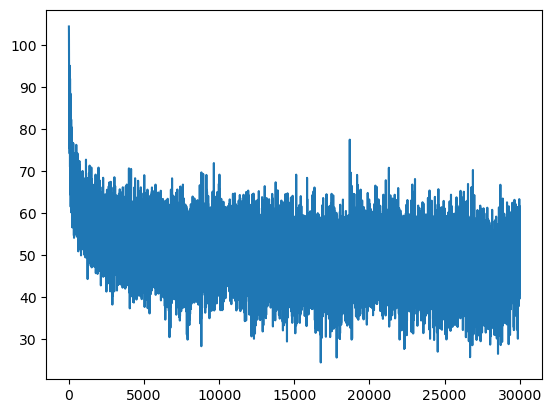

In [40]:
import matplotlib.pyplot as plt

batch_size = 3
input_dim = vocab_size
output_dim= vocab_size
hidden_size=100
params = fr.rnn_params_init(input_dim, hidden_size,output_dim)
H = fr.rnn_hidden_state_init(batch_size,hidden_size)
seq_length = 25

loss_function = lambda F,Y:fr.rnn_loss_grad(F,Y) #,util.loss_grad_least)


epoches = 3
learning_rate = 1e-2
iterations  =10000
losses = []

optimizer = fr.AdaGrad(params,learning_rate)
momentum = 0.9
optimizer = fr.SGD(params,learning_rate,momentum)

for epoch in range(epoches):
    data_it =  character_seq_data_iter_consecutive(data,batch_size,seq_length,vocab_size,100)
   # epoch_losses,param,H = rnn_train(params,data_it,learning_rate,iterations,loss_function,print_n=100)
    epoch_losses,H = rnn_train_epoch(params,data_it,optimizer,iterations,loss_function,print_n=10)
    losses.extend(epoch_losses)  
    #epoch_losses = np.array(epoch_losses).mean()   
    #losses.append(epoch_losses)  
plt.plot(losses[:])

In [52]:
str = predict_rnn(params,"he",200)
print(str)

her Lettents betsel ouct the withing many his offally mands.s
Of and your and arcuay.

EDWURD:
Make haver
ene beed clauchive her engeied, -jaude;
Bave doy
And suvent off matious for ruce mees, Highaters
